# 03 - Análisis Exploratorio de Datos (EDA)

Antes de construir cualquier modelo, necesitamos entender los datos.
El EDA nos permite detectar problemas, entender distribuciones y 
formular hipótesis sobre qué features van a ser relevantes.

## 1. Carga de datos desde Supabase

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from supabase import create_client
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path='../.env')

supabase = create_client(
    os.getenv("SUPABASE_URL"),
    os.getenv("SUPABASE_KEY")
)

# Supabase devuelve máximo 1000 filas por query
# Paginamos hasta traer todos los registros
todos = []
page = 0
page_size = 1000

while True:
    response = supabase.table('asteroids')\
        .select('*')\
        .range(page * page_size, (page + 1) * page_size - 1)\
        .execute()
    
    if not response.data:
        break
        
    todos.extend(response.data)
    print(f"✓ Página {page + 1} — acumulados: {len(todos)}")
    page += 1

df = pd.DataFrame(todos)
print(f"\nTotal: {df.shape[0]} filas, {df.shape[1]} columnas")

✓ Página 1 — acumulados: 1000
✓ Página 2 — acumulados: 2000
✓ Página 3 — acumulados: 3000
✓ Página 4 — acumulados: 4000
✓ Página 5 — acumulados: 5000
✓ Página 6 — acumulados: 6000
✓ Página 7 — acumulados: 7000
✓ Página 8 — acumulados: 8000
✓ Página 9 — acumulados: 9000
✓ Página 10 — acumulados: 10000
✓ Página 11 — acumulados: 11000
✓ Página 12 — acumulados: 11775

Total: 11775 filas, 9 columnas


## 2. Inspección inicial del dataset

In [4]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstadísticas descriptivas:")
print(df.describe())

Dimensiones: (11775, 9)

Tipos de datos:
id                            int64
name                            str
absolute_magnitude_h        float64
diameter_min_km             float64
diameter_max_km             float64
velocity_km_per_hour        float64
miss_distance_km            float64
close_approach_date             str
is_potentially_hazardous       bool
dtype: object

Valores nulos:
id                          0
name                        0
absolute_magnitude_h        0
diameter_min_km             0
diameter_max_km             0
velocity_km_per_hour        0
miss_distance_km            0
close_approach_date         0
is_potentially_hazardous    0
dtype: int64

Estadísticas descriptivas:
                 id  absolute_magnitude_h  diameter_min_km  diameter_max_km  \
count  1.177500e+04          11775.000000     11775.000000     11775.000000   
mean   4.056975e+07             24.767430         0.062871         0.140583   
std    2.267907e+07              2.471404         0.23866

## 3. Balance del target

Lo primero que revisamos en clasificación binaria es cuántos casos 
hay de cada clase. Si hay muchos más "no peligrosos" que "peligrosos", 
el modelo puede aprender a decir siempre "no" y tener alta precisión 
sin aprender nada útil.

In [5]:
conteo = df['is_potentially_hazardous'].value_counts()
porcentaje = df['is_potentially_hazardous'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)
print("\nPorcentaje:")
print(porcentaje.round(2))

Conteo:
is_potentially_hazardous
False    11215
True       560
Name: count, dtype: int64

Porcentaje:
is_potentially_hazardous
False    95.24
True      4.76
Name: proportion, dtype: float64


## 4. Distribución de las features numéricas

Visualizamos cómo se distribuye cada variable para entender 
si hay outliers o distribuciones asimétricas que afecten al modelo.

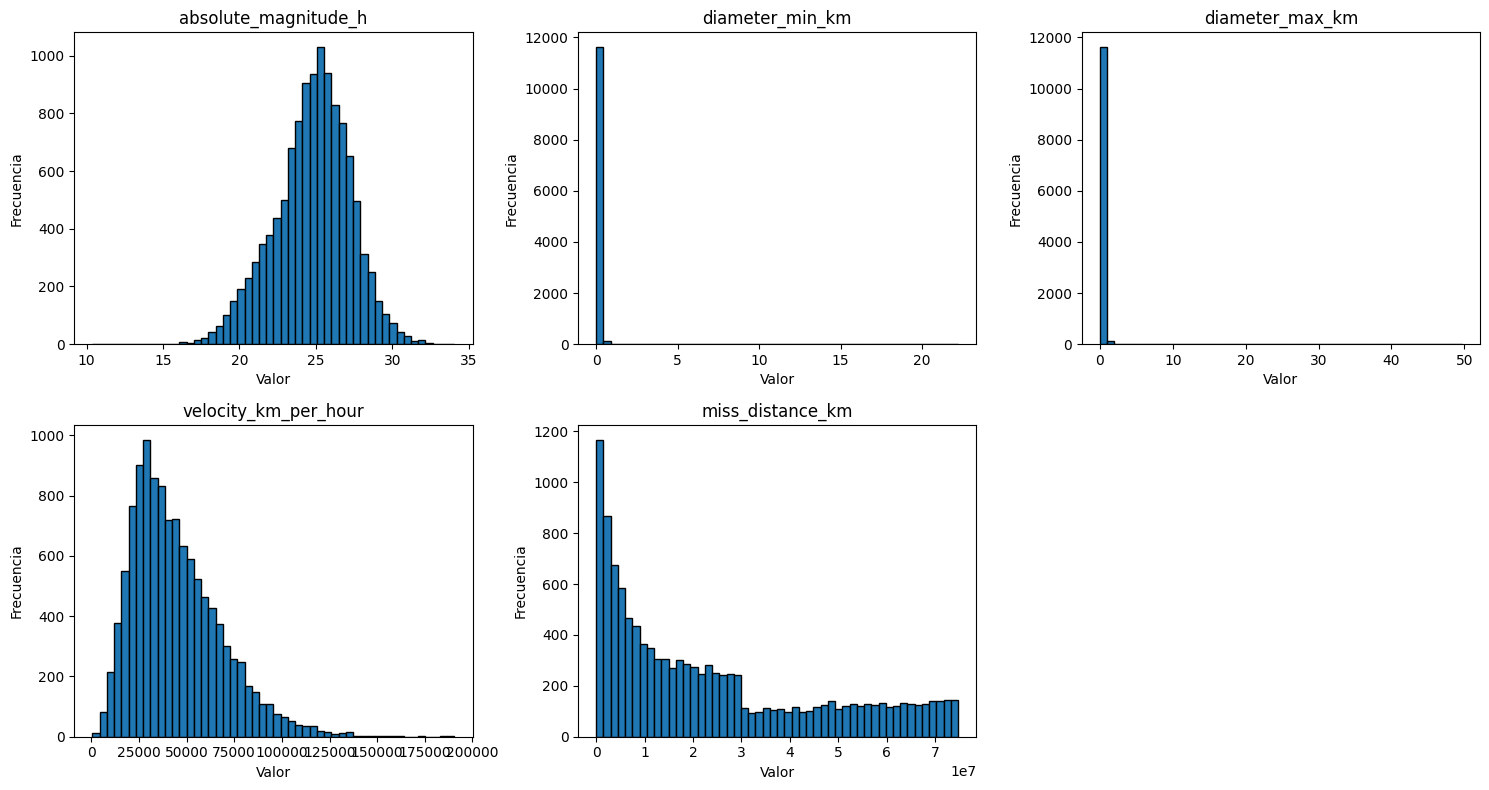

In [6]:
features = ['absolute_magnitude_h', 'diameter_min_km', 
            'diameter_max_km', 'velocity_km_per_hour', 'miss_distance_km']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 5. ¿Cómo se diferencian los asteroides peligrosos de los no peligrosos?

Comparamos la distribución de cada feature separando por clase target.
Esto nos da una idea de qué variables van a ser útiles para el modelo.

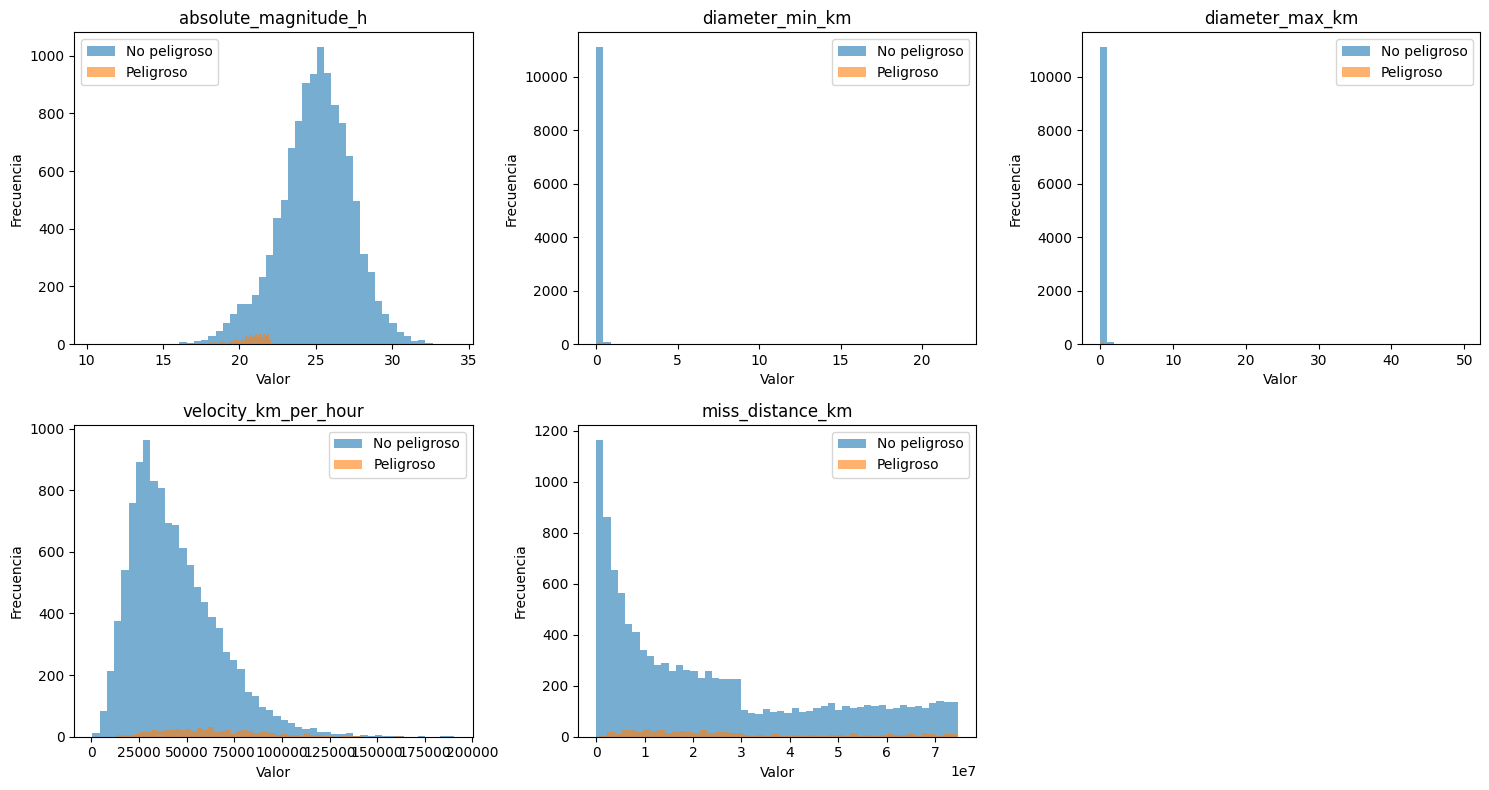

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for label, group in df.groupby('is_potentially_hazardous'):
        axes[i].hist(group[feature], bins=50, alpha=0.6, 
                     label=f'{"Peligroso" if label else "No peligroso"}')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 6. Boxplots por clase

Los boxplots son más útiles que los histogramas para comparar 
dos grupos de distinto tamaño. Muestran mediana, rango intercuartil 
y outliers para cada clase.

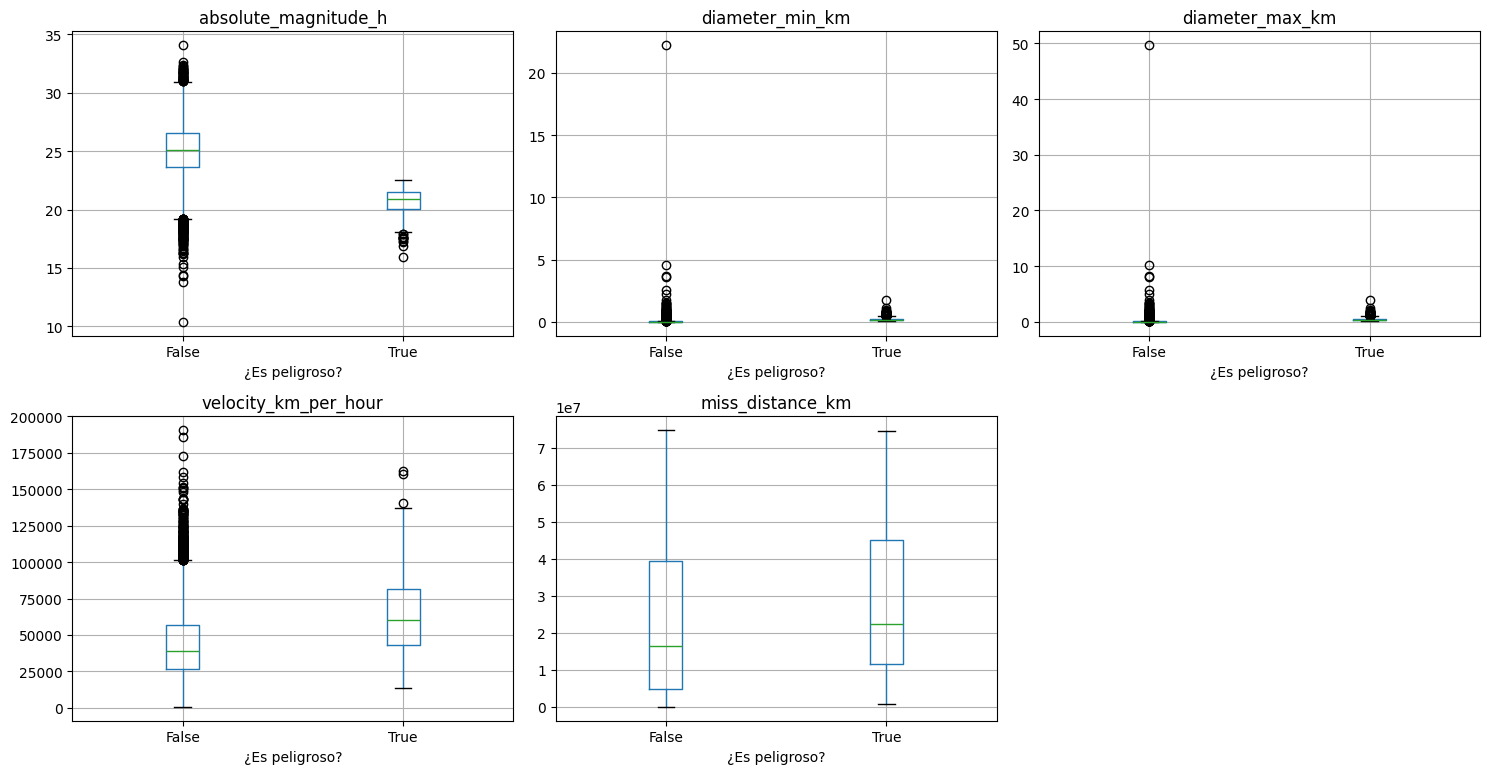

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, by='is_potentially_hazardous', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('¿Es peligroso?')

axes[5].axis('off')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Matriz de correlación

Nos muestra qué features están relacionadas entre sí.
Si dos features están muy correlacionadas, aportan información 
redundante al modelo.

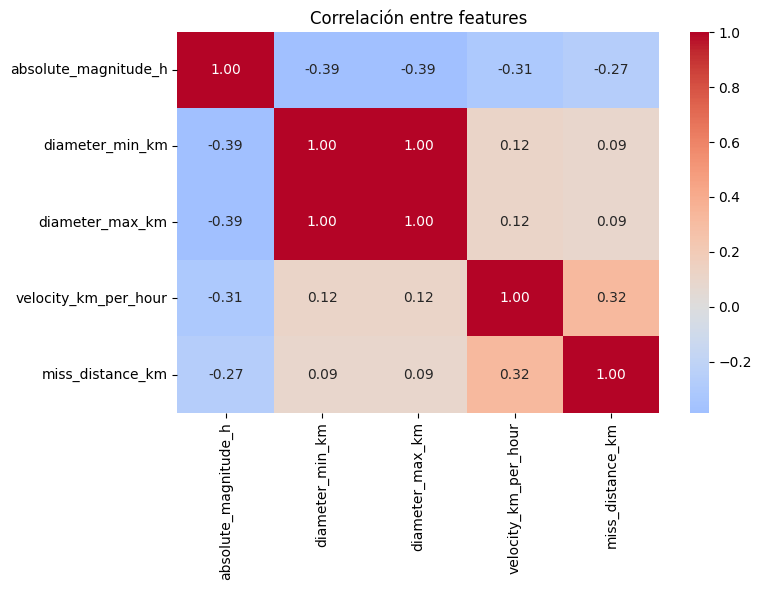

In [9]:
corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre features')
plt.tight_layout()
plt.show()

## Conclusiones del EDA

- **Desbalance de clases:** 95.2% no peligrosos vs 4.8% peligrosos → 
  usar class_weight='balanced' en los modelos
- **Features más discriminativas:** `absolute_magnitude_h` y `velocity_km_per_hour`
- **`miss_distance_km`** aporta menos de lo esperado — las distribuciones se solapan
- **Distribuciones asimétricas:** `diameter`, `velocity` y `miss_distance` requieren 
  transformación logarítmica antes de modelar
- **Multicolinealidad:** `diameter_min_km` y `diameter_max_km` son redundantes → 
  combinar en `diameter_mean_km`

El siguiente paso es el preprocesamiento antes de entrenar los modelos.